<h1 style="color:#1D9E75; font-family:Georgia">
  <center><b>📈 Financial Time Series Analytics & Stock Forecasting System</b></center>
</h1>

<h2 style="color:#F59E0B;"><b>📌 Project Objective</b></h2>
<p>Stock markets generate massive amounts of financial data every day. The objective of this project is to analyze historical stock market data of major technology companies and understand market behavior using financial time-series analytics techniques.</p>
<p>This project focuses on: <b>stock trend analysis, return analysis, rolling statistics, volatility analysis, comparative financial analytics,</b> and <b>educational forecasting</b>.</p>
<p>The project also builds future trend forecasting models for <b>NVIDIA</b> stock using <b>ARIMA</b> and <b>Prophet</b>.</p>

<h2 style="color:#F59E0B;"><b>📊 Selected Companies</b></h2>
<p>This project analyzes the following major technology companies:</p>
<ul>
  <li><code>NVDA</code> → NVIDIA</li>
  <li><code>TSLA</code> → Tesla</li>
  <li><code>AAPL</code> → Apple</li>
  <li><code>MSFT</code> → Microsoft</li>
  <li><code>AMZN</code> → Amazon</li>
  <li><code>GOOGL</code> → Google</li>
</ul>

<h2 style="color:#F59E0B;"><b>📂 Dataset</b></h2>
<p>This project uses a historical stock market dataset containing:</p>
<ul>
  <li>Open price</li>
  <li>High price</li>
  <li>Low price</li>
  <li>Close price</li>
  <li>Trading volume</li>
  <li>Dividends</li>
  <li>Stock split information</li>
  <li>Company ticker</li>
</ul>
<p>The dataset contains <b>491 companies</b> with historical stock records.</p>

<h2 style="color:#F59E0B;"><b>🎯 Main Goals</b></h2>
<ol>
  <li>Analyze historical stock market trends</li>
  <li>Compare company-wise performance</li>
  <li>Measure stock volatility and risk</li>
  <li>Analyze daily stock returns</li>
  <li>Understand rolling market behavior</li>
  <li>Detect bullish and bearish trends</li>
  <li>Forecast NVIDIA future stock movement</li>
  <li>Generate financial business insights</li>
</ol>

<h2 style="color:#F59E0B;"><b>🔄 Project Workflow</b></h2>
<ol>
  <li>Import Libraries</li>
  <li>Load Dataset</li>
  <li>Data Understanding</li>
  <li>Data Cleaning</li>
  <li>DateTime Processing</li>
  <li>Feature Engineering</li>
  <li>Exploratory Data Analysis</li>
  <li>Return Analysis</li>
  <li>Rolling Statistics</li>
  <li>Volatility Analysis</li>
  <li>Trend Signal Detection</li>
  <li>Company Comparison</li>
  <li>ARIMA Forecasting</li>
  <li>Prophet Forecasting</li>
  <li>Model Evaluation</li>
  <li>Final Insights</li>
</ol>

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Import Libraries</b>
</h1>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

from scipy.stats import zscore

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Time Series
from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Load Dataset</b>
</h1>

In [6]:
df = pd.read_csv("stock_details_5_years.csv")

In [7]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


In [8]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
602957,2023-11-29 00:00:00-05:00,26.360001,26.397499,26.120001,26.150000,1729147,0.0,0.0,PPL
602958,2023-11-29 00:00:00-05:00,27.680000,28.535000,27.680000,28.350000,1940066,0.0,0.0,FITB
602959,2023-11-29 00:00:00-05:00,75.940002,76.555000,75.257500,75.610001,298699,0.0,0.0,IFF
602960,2023-11-29 00:00:00-05:00,45.230000,45.259998,44.040001,44.209999,2217579,0.0,0.0,CCJ
602961,2023-11-29 00:00:00-05:00,84.629997,84.995003,83.529999,83.889999,830092,0.0,0.0,LYV


In [9]:
df.shape

(602962, 9)

In [10]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Company'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 602962 entries, 0 to 602961
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          602962 non-null  str    
 1   Open          602962 non-null  float64
 2   High          602962 non-null  float64
 3   Low           602962 non-null  float64
 4   Close         602962 non-null  float64
 5   Volume        602962 non-null  int64  
 6   Dividends     602962 non-null  float64
 7   Stock Splits  602962 non-null  float64
 8   Company       602962 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 57.6 MB


In [12]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,602962.000000,602962.000000,602962.000000,602962.000000,6.029620e+05,602962.00000,602962.000000
mean,140.074711,141.853492,138.276316,140.095204,5.895601e+06,0.00731,0.000344
std,275.401725,279.003191,271.895276,275.477969,1.381596e+07,0.12057,0.050607
min,1.052425,1.061195,1.026114,1.034884,0.000000e+00,0.00000,0.000000
25%,39.566159,40.056222,39.058151,39.563746,1.031500e+06,0.00000,0.000000
50%,79.177964,80.125563,78.193820,79.177906,2.228700e+06,0.00000,0.000000
75%,157.837190,159.746317,155.841609,157.847153,5.277400e+06,0.00000,0.000000
max,6490.259766,6525.000000,6405.000000,6509.350098,1.123003e+09,35.00000,20.000000


<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Data Understanding</b>
</h1>

In [13]:
df["Company"].nunique()

491

In [14]:
df["Company"].unique()

<ArrowStringArray>
[ 'AAPL',  'MSFT', 'GOOGL',  'AMZN',  'NVDA',  'META',  'TSLA',   'LLY',
     'V',   'TSM',
 ...
  'CPNG',  'COIN',   'GFS',    'NU',   'CEG',   'HLN',  'MBLY',  'GEHC',
  'KVUE',   'ARM']
Length: 491, dtype: str

In [15]:
df["Company"].value_counts()

Company
AAPL     1258
MSFT     1258
GOOGL    1258
AMZN     1258
NVDA     1258
         ... 
HLN       341
MBLY      275
GEHC      240
KVUE      145
ARM        54
Name: count, Length: 491, dtype: int64

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Filter Selected Companies</b>
</h1>

In [16]:
selected_companies = [
    "NVDA",
    "TSLA",
    "AAPL",
    "MSFT",
    "AMZN",
    "GOOGL"
]

df = df[df["Company"].isin(selected_companies)]

In [17]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


In [18]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
602472,2023-11-29 00:00:00-05:00,383.760010,384.299988,377.440002,378.325012,12302543,0.0,0.0,MSFT
602473,2023-11-29 00:00:00-05:00,137.570007,138.287994,135.220001,135.802505,11502356,0.0,0.0,GOOGL
602474,2023-11-29 00:00:00-05:00,147.850006,148.539993,145.970001,146.362396,20535262,0.0,0.0,AMZN
602475,2023-11-29 00:00:00-05:00,483.790008,487.619904,478.635406,480.734985,20498046,0.0,0.0,NVDA
602477,2023-11-29 00:00:00-05:00,249.210007,252.750000,245.360001,247.947998,77383915,0.0,0.0,TSLA


<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Data Cleaning</b>
</h1>

In [19]:
# Check missing values
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Company         0
dtype: int64

In [20]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [22]:
# Convert Date Column
df["Date"] = pd.to_datetime(df["Date"],utc=True)

In [23]:
df = df.sort_values(by=["Company", "Date"])

In [24]:
df.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 05:00:00+00:00,43.829761,43.863354,42.639594,43.083508,167080000,0.0,0.0,AAPL
458,2018-11-30 05:00:00+00:00,43.261071,43.270671,42.478826,42.850754,158126000,0.0,0.0,AAPL
916,2018-12-03 05:00:00+00:00,44.261681,44.376858,43.481835,44.348064,163210000,0.0,0.0,AAPL
1374,2018-12-04 05:00:00+00:00,43.419445,43.764977,42.296468,42.397247,165377200,0.0,0.0,AAPL
1832,2018-12-06 05:00:00+00:00,41.214280,41.938938,40.892744,41.924541,172393600,0.0,0.0,AAPL
2290,2018-12-07 05:00:00+00:00,41.629402,41.869354,40.384046,40.429638,169126400,0.0,0.0,AAPL
2749,2018-12-10 05:00:00+00:00,39.592200,40.813558,39.191479,40.695984,248104000,0.0,0.0,AAPL
3208,2018-12-11 05:00:00+00:00,41.190283,41.221474,40.072102,40.463226,189126800,0.0,0.0,AAPL
3667,2018-12-12 05:00:00+00:00,40.887936,41.252665,40.556804,40.576000,142510800,0.0,0.0,AAPL
4126,2018-12-13 05:00:00+00:00,40.909533,41.408635,40.683977,41.019909,127594400,0.0,0.0,AAPL


In [25]:
df[df["Company"] == "NVDA"].tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
600511,2023-11-22 05:00:00+00:00,498.519989,503.350006,476.899994,487.160004,89942000,0.0,0.0,NVDA
601002,2023-11-24 05:00:00+00:00,484.700012,489.209992,477.450012,477.760010,29464500,0.0,0.0,NVDA
601493,2023-11-27 05:00:00+00:00,478.000000,485.299988,476.519989,482.420013,39566200,0.0,0.0,NVDA
601984,2023-11-28 05:00:00+00:00,482.359985,483.230011,474.730011,478.209992,40089000,0.0,0.0,NVDA
602475,2023-11-29 05:00:00+00:00,483.790008,487.619904,478.635406,480.734985,20498046,0.0,0.0,NVDA


In [26]:
df = df.reset_index(drop=True)

In [27]:
df[["Company", "Date"]].head(20)

,Company,Date
0,AAPL,2018-11-29 05:00:00+00:00
1,AAPL,2018-11-30 05:00:00+00:00
2,AAPL,2018-12-03 05:00:00+00:00
3,AAPL,2018-12-04 05:00:00+00:00
4,AAPL,2018-12-06 05:00:00+00:00
5,AAPL,2018-12-07 05:00:00+00:00
6,AAPL,2018-12-10 05:00:00+00:00
7,AAPL,2018-12-11 05:00:00+00:00
8,AAPL,2018-12-12 05:00:00+00:00
9,AAPL,2018-12-13 05:00:00+00:00


In [28]:
df[df["Company"] == "NVDA"].tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
6285,2023-11-22 05:00:00+00:00,498.519989,503.350006,476.899994,487.160004,89942000,0.0,0.0,NVDA
6286,2023-11-24 05:00:00+00:00,484.700012,489.209992,477.450012,477.760010,29464500,0.0,0.0,NVDA
6287,2023-11-27 05:00:00+00:00,478.000000,485.299988,476.519989,482.420013,39566200,0.0,0.0,NVDA
6288,2023-11-28 05:00:00+00:00,482.359985,483.230011,474.730011,478.209992,40089000,0.0,0.0,NVDA
6289,2023-11-29 05:00:00+00:00,483.790008,487.619904,478.635406,480.734985,20498046,0.0,0.0,NVDA


In [29]:
df.shape

(7548, 9)

<p><i>The dataset is sorted by company and date so that stock data follows the correct time order from oldest to newest. This is important for trend analysis, rolling averages, and forecasting.</i></p>

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
DateTime Processing</b>
</h1>

In [31]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Month_Name"] = df["Date"].dt.month_name()

df["Quarter"] = df["Date"].dt.quarter

df["Weekday"] = df["Date"].dt.day_name()

In [32]:
df[["Date","Year","Month","Month_Name","Quarter","Weekday"]].head()

,Date,Year,Month,Month_Name,Quarter,Weekday
0,2018-11-29 05:00:00+00:00,2018,11,November,4,Thursday
1,2018-11-30 05:00:00+00:00,2018,11,November,4,Friday
2,2018-12-03 05:00:00+00:00,2018,12,December,4,Monday
3,2018-12-04 05:00:00+00:00,2018,12,December,4,Tuesday
4,2018-12-06 05:00:00+00:00,2018,12,December,4,Thursday


In [33]:
df[["Date","Year","Month","Month_Name","Quarter","Weekday"]].tail()

,Date,Year,Month,Month_Name,Quarter,Weekday
7543,2023-11-22 05:00:00+00:00,2023,11,November,4,Wednesday
7544,2023-11-24 05:00:00+00:00,2023,11,November,4,Friday
7545,2023-11-27 05:00:00+00:00,2023,11,November,4,Monday
7546,2023-11-28 05:00:00+00:00,2023,11,November,4,Tuesday
7547,2023-11-29 05:00:00+00:00,2023,11,November,4,Wednesday


<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Feature Engineering</b>
</h1>

In [58]:
# daily return

df["Daily_Return"] = (df.groupby("Company")["Close"].pct_change()* 100).round(2)

In [59]:
df[["Company","Close","Daily_Return"]].head(10)

,Company,Close,Daily_Return
0,AAPL,43.083508,NaN
1,AAPL,42.850754,-0.54
2,AAPL,44.348064,3.49
3,AAPL,42.397247,-4.40
4,AAPL,41.924541,-1.11
5,AAPL,40.429638,-3.57
6,AAPL,40.695984,0.66
7,AAPL,40.463226,-0.57
8,AAPL,40.576000,0.28
9,AAPL,41.019909,1.09


In [51]:
# Price Range

df["Price_Range"] = (df["High"] - df["Low"])

In [52]:
df[["High","Low","Price_Range"]].head()

,High,Low,Price_Range
0,43.863354,42.639594,1.223760
1,43.270671,42.478826,0.791845
2,44.376858,43.481835,0.895023
3,43.764977,42.296468,1.468509
4,41.938938,40.892744,1.046194


In [53]:
# Price Change
df["Price_Change"] = (df["Close"] - df["Open"])

In [56]:
df["Price_Change_Percent"] = (((df["Close"] - df["Open"])/ df["Open"]) * 100).round(2).astype(str) + "%"

In [57]:
df[["Open","Close","Price_Change","Price_Change_Percent"]].head()

,Open,Close,Price_Change,Price_Change_Percent
0,43.829761,43.083508,-0.746253,-1.7%
1,43.261071,42.850754,-0.410317,-0.95%
2,44.261681,44.348064,0.086383,0.2%
3,43.419445,42.397247,-1.022197,-2.35%
4,41.214280,41.924541,0.710262,1.72%


In [61]:
# Cumulative Return
df["Cumulative_Return"] = (df.groupby("Company")["Daily_Return"].cumsum())

In [62]:
df[["Company","Daily_Return","Cumulative_Return"]].head(10)

,Company,Daily_Return,Cumulative_Return
0,AAPL,NaN,NaN
1,AAPL,-0.54,-0.54
2,AAPL,3.49,2.95
3,AAPL,-4.40,-1.45
4,AAPL,-1.11,-2.56
5,AAPL,-3.57,-6.13
6,AAPL,0.66,-5.47
7,AAPL,-0.57,-6.04
8,AAPL,0.28,-5.76
9,AAPL,1.09,-4.67


In [63]:
df["Daily_Return_Display"] = (df["Daily_Return"].astype(str) + "%")

df["Cumulative_Return_Display"] = (df["Cumulative_Return"].astype(str) + "%")

In [64]:
df[["Daily_Return_Display","Cumulative_Return_Display"]].head()

,Daily_Return_Display,Cumulative_Return_Display
0,NaN,NaN
1,-0.54%,-0.54%
2,3.49%,2.95%
3,-4.4%,-1.4500000000000002%
4,-1.11%,-2.5600000000000005%


In [65]:
# 7-Days Moving Average
df["Days_7"] = (df.groupby("Company")["Close"].transform(lambda x: x.rolling(7).mean()))

In [66]:
df[["Company","Close","Days_7"]].head(15)

,Company,Close,Days_7
0,AAPL,43.083508,NaN
1,AAPL,42.850754,NaN
2,AAPL,44.348064,NaN
3,AAPL,42.397247,NaN
4,AAPL,41.924541,NaN
5,AAPL,40.429638,NaN
6,AAPL,40.695984,42.247105
7,AAPL,40.463226,41.872779
8,AAPL,40.576000,41.547815
9,AAPL,41.019909,41.072364


In [67]:
#  30 Days Moving Average
df["Days_30"] = (df.groupby("Company")["Close"].transform(lambda x: x.rolling(30).mean()))

In [68]:
df[["Company","Close","Days_30"]].head(50)

,Company,Close,Days_30
0,AAPL,43.083508,NaN
1,AAPL,42.850754,NaN
2,AAPL,44.348064,NaN
3,AAPL,42.397247,NaN
4,AAPL,41.924541,NaN
5,AAPL,40.429638,NaN
6,AAPL,40.695984,NaN
7,AAPL,40.463226,NaN
8,AAPL,40.576000,NaN
9,AAPL,41.019909,NaN


<p><i>Feature engineering creates new financial indicators that help us identify the measure of stock performance, price movement, and market behavior.</i></p>

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Chart Analysis</b>
</h1>

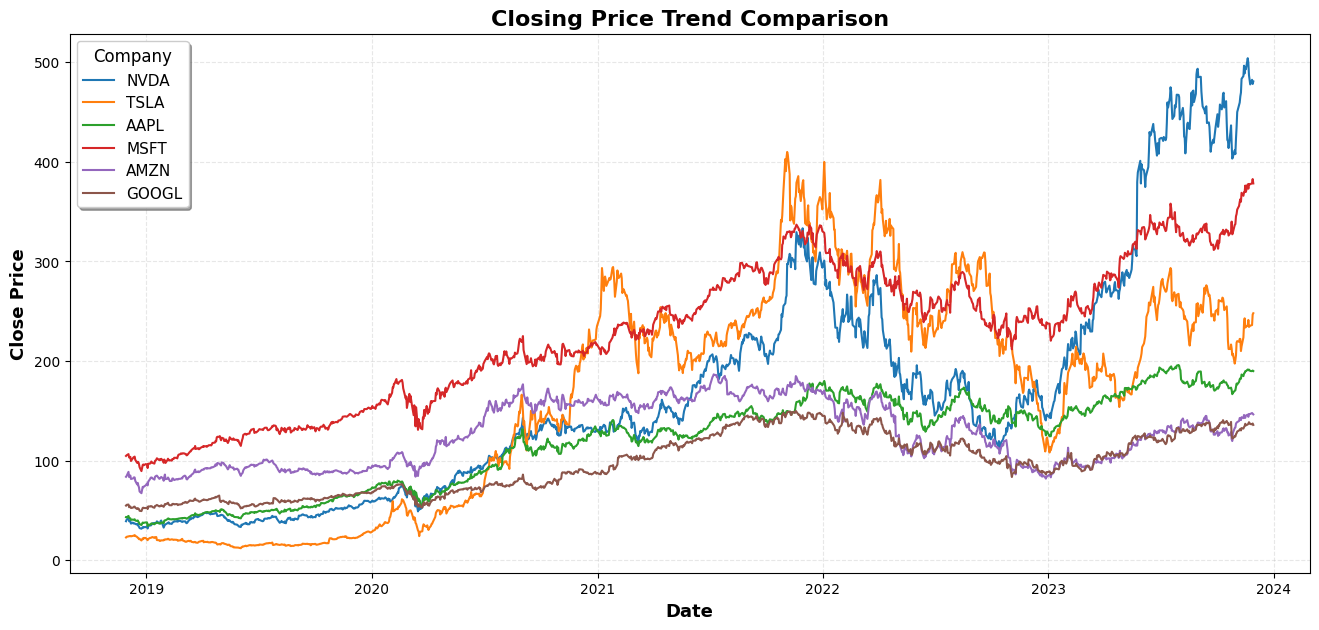

In [77]:
# Closing Price Trend Analysis

plt.figure(figsize=(16,7))

for company in selected_companies:
    company_df = df[df["Company"] == company]
    plt.plot(company_df["Date"],company_df["Close"],label=company)

plt.title("Closing Price Trend Comparison",fontsize=16,fontweight="bold")

plt.xlabel("Date", fontsize=13,fontweight="bold")

plt.ylabel("Close Price",fontsize=13,fontweight="bold")

plt.legend(title="Company",fontsize=11,title_fontsize=12,frameon=True,shadow=True)

plt.grid(alpha=0.3,linestyle="--")

plt.show()

<p><i>NVDA started very low in 2019 but grew the most — crossing $500 by 2024. TSLA had a huge spike around 2021-22 but then dropped back down. The rest — AAPL, MSFT, AMZN and GOOGL — grew slowly and steadily throughout without any major crashes.</i></p>

In [79]:
# Trading Volume Analysis

volume_analysis = (df.groupby("Company")["Volume"].mean().sort_values(ascending=False).round(0).astype(int))
volume_analysis.apply(lambda x: f"{x:,}")

Company
TSLA     133,927,533
AAPL     103,802,467
AMZN      77,623,982
NVDA      46,708,996
GOOGL     33,870,094
MSFT      29,784,870
Name: Volume, dtype: str

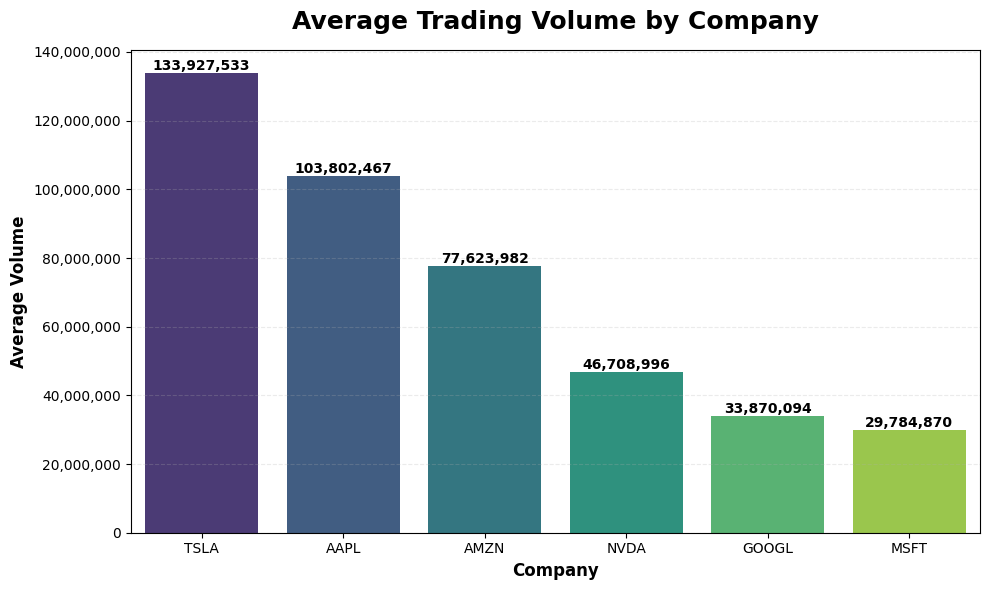

In [83]:
plt.figure(figsize=(10,6))

bars = sns.barplot(x=volume_analysis.index,y=volume_analysis.values,palette="viridis")

plt.title("Average Trading Volume by Company",fontsize=18,fontweight="bold",pad=15)

plt.xlabel("Company",fontsize=12,fontweight="bold")

plt.ylabel("Average Volume",fontsize=12,fontweight="bold")

plt.ticklabel_format(style='plain', axis='y')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar in bars.patches:
    height = bar.get_height()

    plt.text(bar.get_x() + bar.get_width()/2,height,
        f"{int(height):,}",
        ha="center",va="bottom",fontsize=10,fontweight="bold"
    )

plt.grid(axis="y",alpha=0.25,linestyle="--")

plt.tight_layout()

plt.show()

<p><i>Trading volume analysis helps identify the companies with higher market activity and best investor.</i></p>

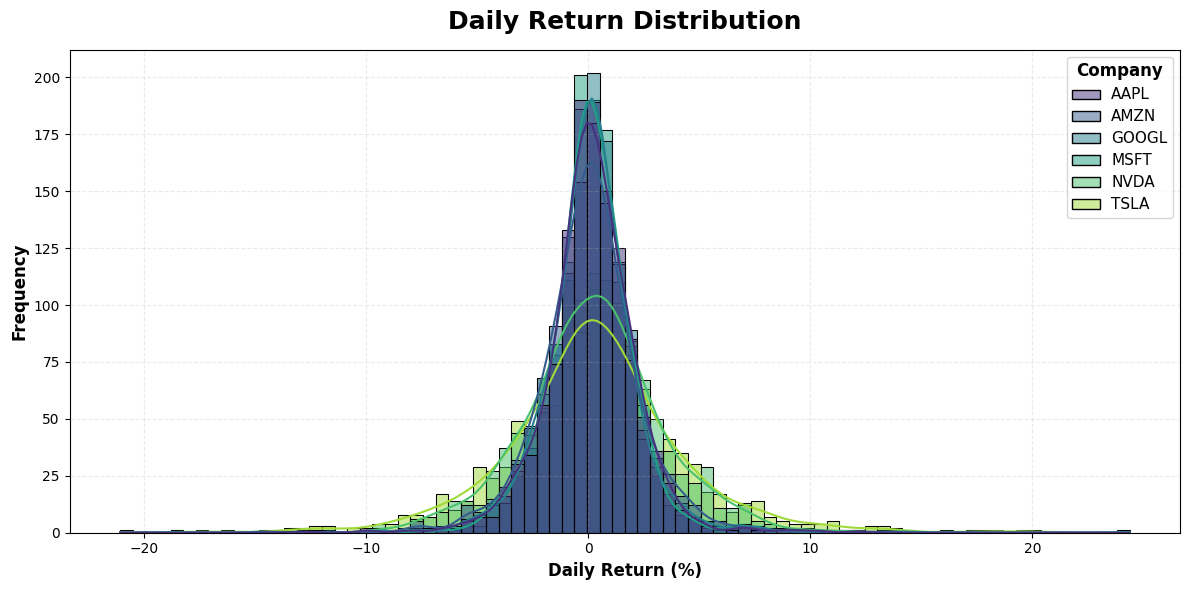

In [87]:
# Daily Return Analysis

plt.figure(figsize=(12,6))

ax = sns.histplot(data=df,x="Daily_Return",hue="Company",bins=80,kde=True,palette="viridis",alpha=0.5)

plt.title("Daily Return Distribution",fontsize=18,fontweight="bold",pad=15)

plt.xlabel("Daily Return (%)",fontsize=12,fontweight="bold")

plt.ylabel("Frequency",fontsize=12,fontweight="bold")

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(alpha=0.25,linestyle="--")

legend = ax.get_legend()

legend.set_title("Company")

plt.setp(legend.get_texts(),fontsize=11)

plt.setp(legend.get_title(),fontsize=12,fontweight="bold")

plt.tight_layout()

plt.show()

<p><i>Daily return analysis measures how much stock prices change from one trading day to another.

According to this visualizatyion:

AAPL, AMZN, GOOGL, MSFT — all bunched tightly around 0%. Very rarely move more than ±5% in a day. Safe and predictable.

TSLA and NVDA — the green spread-out curves. These two move wildly — sometimes ±10%, ±15%, even ±25% in a single day.

Simple takeaway:
TSLA and NVDA are high risk, high reward stocks. On a good day they jump 20%+, on a bad day they crash hard too. The other 4 companies are  small daily moves, lower risk.</i></p>

In [88]:
# Monthly Trend Analysis

monthly_trend = (df.groupby(["Company", "Month_Name"])["Close"].mean().reset_index())

In [89]:
monthly_trend.head(10)

,Company,Month_Name,Close
0,AAPL,April,113.347552
1,AAPL,August,132.380234
2,AAPL,December,110.184690
3,AAPL,February,113.011054
4,AAPL,January,108.073062
5,AAPL,July,123.439749
6,AAPL,June,116.836253
7,AAPL,March,110.798611
8,AAPL,May,113.399105
9,AAPL,November,130.946467


In [92]:
monthly_trend[monthly_trend["Company"] == "AMZN"].head(12)

,Company,Month_Name,Close
12,AMZN,April,125.579412
13,AMZN,August,137.896847
14,AMZN,December,118.854400
15,AMZN,February,120.169416
16,AMZN,January,116.184321
17,AMZN,July,135.958337
18,AMZN,June,126.944627
19,AMZN,March,117.550915
20,AMZN,May,119.251139
21,AMZN,November,130.935201


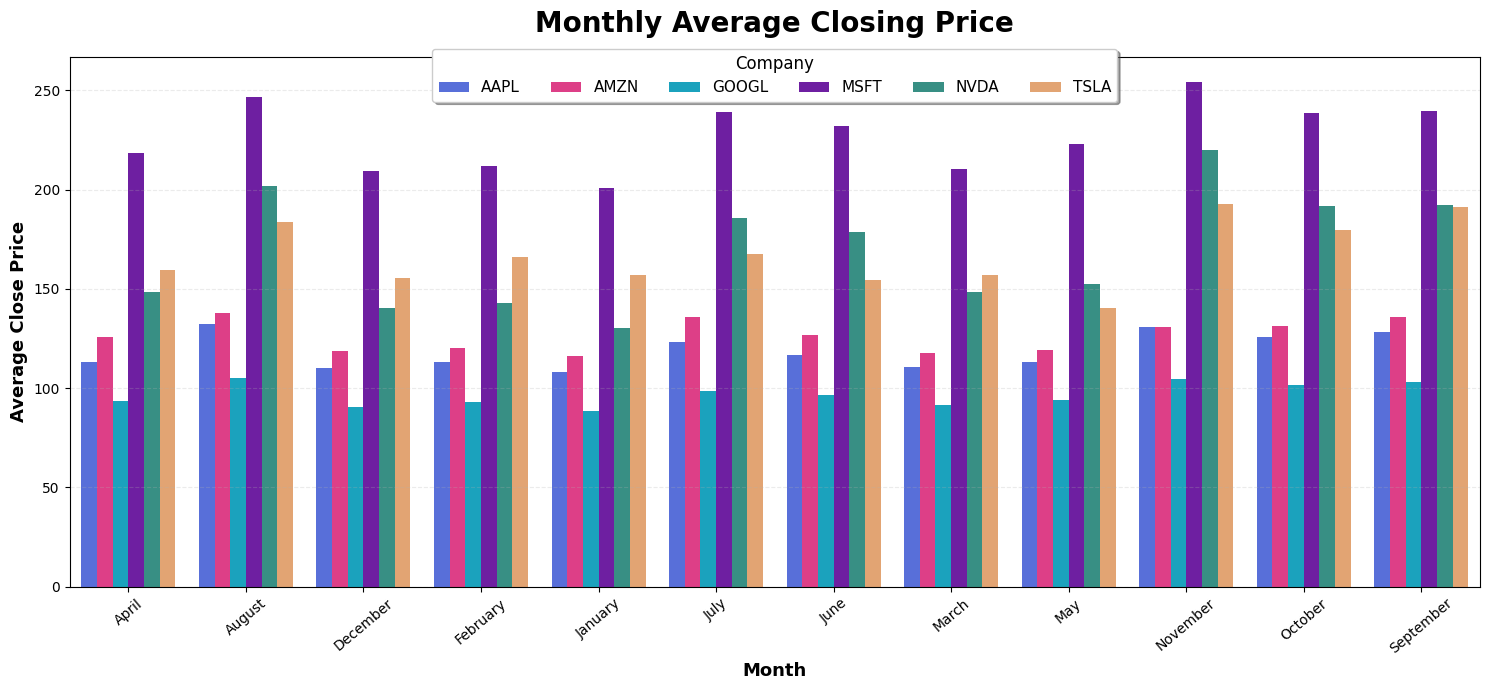

In [98]:
plt.figure(figsize=(15,7))

custom_colors = ["#4361EE", "#F72585","#00B4D8","#7209B7","#2A9D8F","#F4A261"]

sns.barplot(data=monthly_trend,x="Month_Name",y="Close",hue="Company",palette=custom_colors)

plt.title("Monthly Average Closing Price",fontsize=20,fontweight="bold",pad=18)

plt.xlabel("Month",fontsize=13,fontweight="bold")

plt.ylabel("Average Close Price",fontsize=13,fontweight="bold")

plt.xticks(rotation=40,fontsize=10)

plt.yticks(fontsize=10)

plt.legend(title="Company",title_fontsize=12,fontsize=11,ncol=6,
    frameon=True,shadow=True,loc="upper center",bbox_to_anchor=(0.5, 1.03))

plt.grid(axis="y",alpha=0.25,linestyle="--")

plt.tight_layout()

plt.show()

<p><i>Monthly analysis helps identify seasonal market behavior and company performance across months.</p></i>

In [99]:
# Yearly Growth Analysis

yearly_growth = (df.groupby(["Company", "Year"])["Close"].mean().reset_index())

In [101]:
yearly_growth.tail(12)

,Company,Year,Close
24,NVDA,2018,36.034553
25,NVDA,2019,43.401928
26,NVDA,2020,98.632214
27,NVDA,2021,194.906720
28,NVDA,2022,185.510739
29,NVDA,2023,355.161406
30,TSLA,2018,22.951524
31,TSLA,2019,18.235347
32,TSLA,2020,96.665689
33,TSLA,2021,259.998162


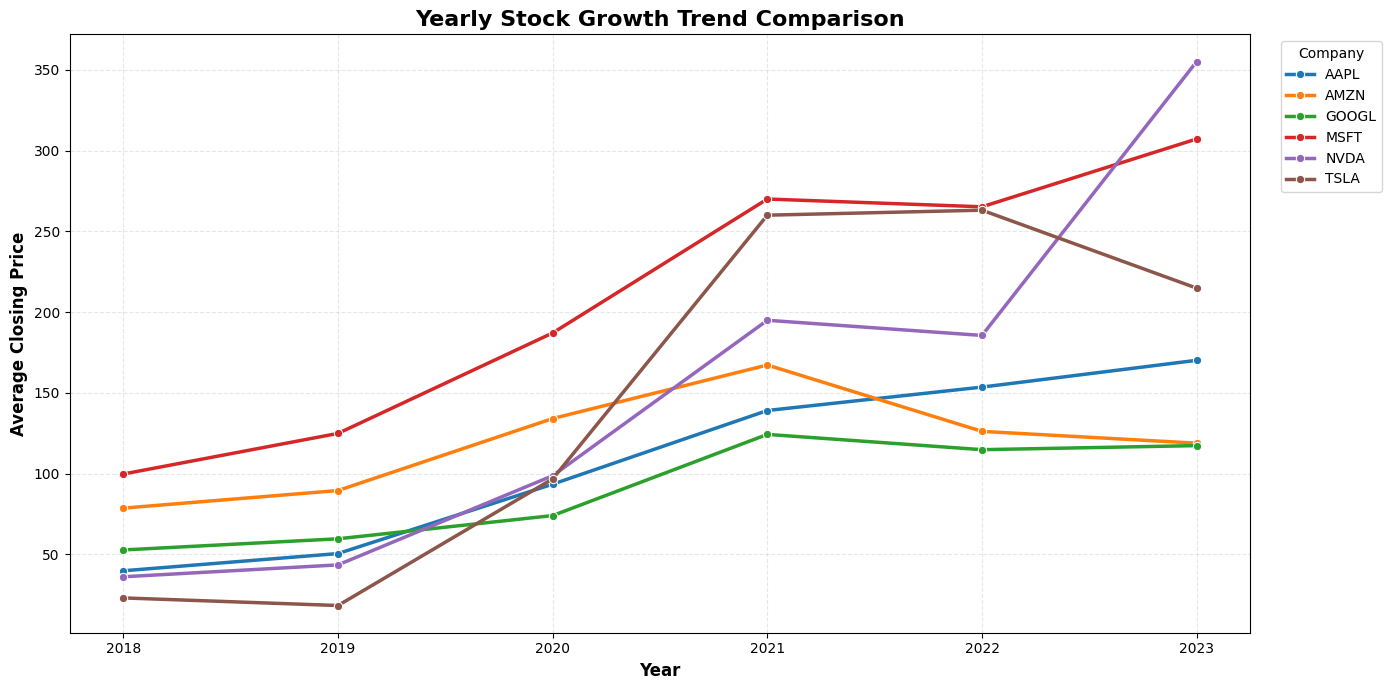

In [103]:
plt.figure(figsize=(14,7))

sns.lineplot(data=yearly_growth,x="Year",y="Close",hue="Company",marker="o",linewidth=2.5)

plt.title("Yearly Stock Growth Trend Comparison",fontsize=16,fontweight="bold")

plt.xlabel("Year",fontsize=12,fontweight="bold")

plt.ylabel("Average Closing Price",fontsize=12,fontweight="bold")

plt.xticks(fontsize=10)

plt.yticks(fontsize=10)

plt.legend(title="Company",bbox_to_anchor=(1.02, 1),loc="upper left")

plt.grid(alpha=0.3,linestyle="--")

plt.tight_layout()

plt.show()

<p><i>Yearly growth analysis shows long-term stock performance.</p></i>

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Rolling Statistics Analysis</b>
</h1>

In [104]:
nvda_df = df[df["Company"] == "NVDA"].copy()

In [105]:
nvda_df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,Year,...,Weekday,Daily_Return,Price_Change,Price_Range,Price_Change_Percent,Cumulative_Return,Daily_Return_Display,Cumulative_Return_Display,Days_7,Days_30
5032,2018-11-29 05:00:00+00:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA,2018,...,Thursday,NaN,-0.654931,1.329708,-1.65%,NaN,NaN,NaN,NaN,NaN
5033,2018-11-30 05:00:00+00:00,39.134605,40.650374,38.631003,40.543697,72956400,0.00,0.0,NVDA,2018,...,Friday,3.86,1.409092,2.019370,3.6%,3.86,3.86%,3.86%,NaN,NaN
5034,2018-12-03 05:00:00+00:00,42.818601,43.334604,41.513699,42.183514,89080400,0.00,0.0,NVDA,2018,...,Monday,4.04,-0.635088,1.820906,-1.48%,7.90,4.04%,7.9%,NaN,NaN
5035,2018-12-04 05:00:00+00:00,41.736964,41.786580,38.824505,38.975834,81211200,0.00,0.0,NVDA,2018,...,Tuesday,-7.60,-2.761131,2.962075,-6.62%,0.30,-7.6%,0.2999999999999998%,NaN,NaN
5036,2018-12-06 05:00:00+00:00,37.569232,39.318197,37.412940,39.268578,69230800,0.00,0.0,NVDA,2018,...,Thursday,0.75,1.699346,1.905256,4.52%,1.05,0.75%,1.0499999999999998%,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6285,2023-11-22 05:00:00+00:00,498.519989,503.350006,476.899994,487.160004,89942000,0.00,0.0,NVDA,2023,...,Wednesday,-2.46,-11.359985,26.450012,-2.28%,319.82,-2.46%,319.82%,494.844286,452.906333
6286,2023-11-24 05:00:00+00:00,484.700012,489.209992,477.450012,477.760010,29464500,0.00,0.0,NVDA,2023,...,Friday,-1.93,-6.940002,11.759979,-1.43%,317.89,-1.93%,317.89%,492.158574,453.183333
6287,2023-11-27 05:00:00+00:00,478.000000,485.299988,476.519989,482.420013,39566200,0.00,0.0,NVDA,2023,...,Monday,0.98,4.420013,8.779999,0.92%,318.87,0.98%,318.87%,491.235718,454.110334
6288,2023-11-28 05:00:00+00:00,482.359985,483.230011,474.730011,478.209992,40089000,0.00,0.0,NVDA,2023,...,Tuesday,-0.87,-4.149994,8.500000,-0.86%,318.00,-0.87%,318.0%,488.865718,454.685667


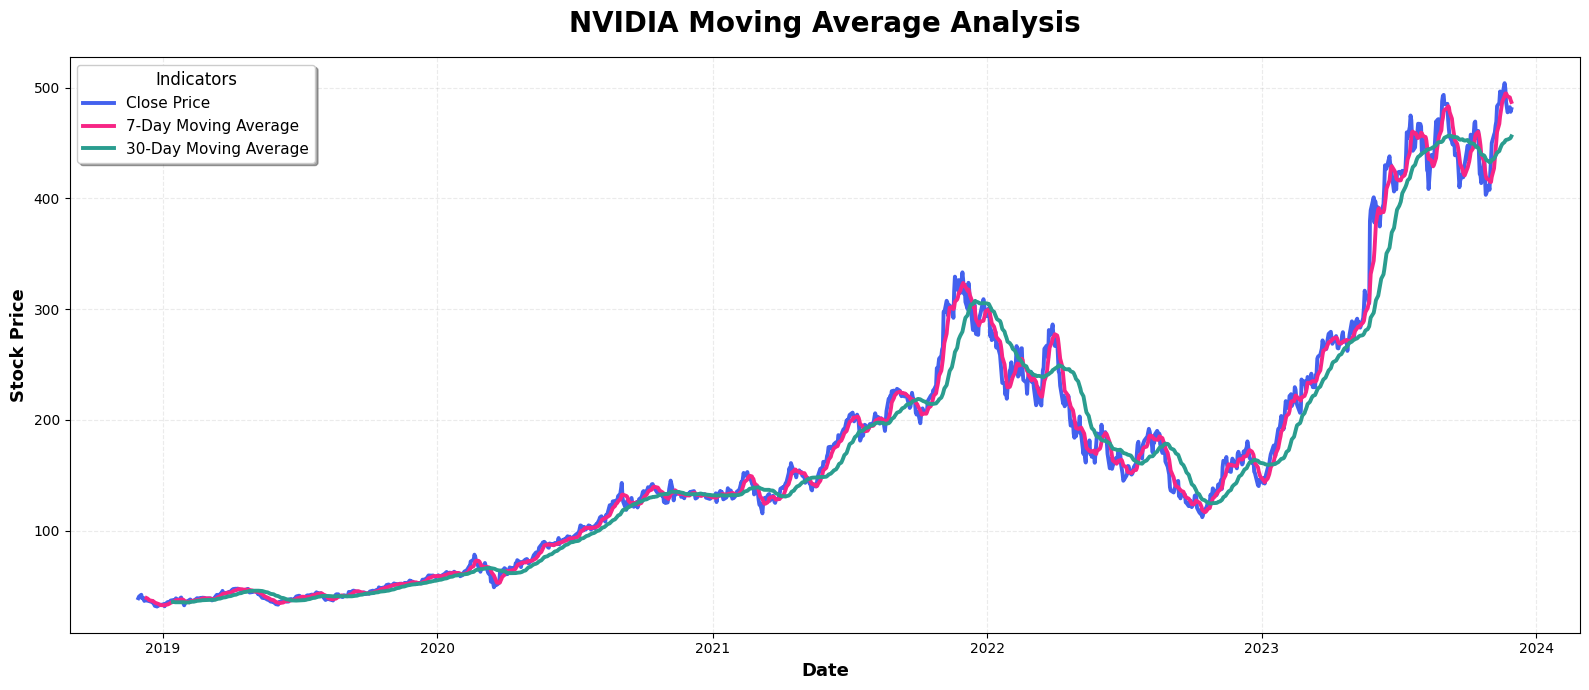

In [109]:
plt.figure(figsize=(16,7))

# Close Price
plt.plot(nvda_df["Date"],nvda_df["Close"],label="Close Price",linewidth=2.8,color="#4361EE")

# 7 Days Moving Average
plt.plot(nvda_df["Date"],nvda_df["Days_7"],label="7-Day Moving Average",linewidth=2.8,color="#F72585")

# 30 Days Moving Average
plt.plot(nvda_df["Date"],nvda_df["Days_30"],label="30-Day Moving Average",linewidth=2.8,color="#2A9D8F")

plt.title("NVIDIA Moving Average Analysis",fontsize=20,fontweight="bold",pad=18)

plt.xlabel("Date",fontsize=13,fontweight="bold")

plt.ylabel("Stock Price",fontsize=13,fontweight="bold")

plt.legend(fontsize=11,title="Indicators",title_fontsize=12,frameon=True,shadow=True)

plt.grid(alpha=0.25,linestyle="--")

plt.tight_layout()

plt.show()

<p><i>Rolling averages help identify short-term and long-term market trends.</i></p>

In [110]:
# Volatility Analysis

nvda_df["Rolling_Volatility"] = (nvda_df["Daily_Return"].rolling(window=30).std())

In [112]:
nvda_df["Rolling_Volatility"].head(50)

5032         NaN
5033         NaN
5034         NaN
5035         NaN
5036         NaN
5037         NaN
5038         NaN
5039         NaN
5040         NaN
5041         NaN
5042         NaN
5043         NaN
5044         NaN
5045         NaN
5046         NaN
5047         NaN
5048         NaN
5049         NaN
5050         NaN
5051         NaN
5052         NaN
5053         NaN
5054         NaN
5055         NaN
5056         NaN
5057         NaN
5058         NaN
5059         NaN
5060         NaN
5061         NaN
5062    3.617436
5063    3.540315
5064    3.472458
5065    3.252039
5066    3.386371
5067    3.149064
5068    3.276673
5069    3.246921
5070    4.146224
5071    4.225602
5072    4.303758
5073    4.374190
5074    4.355336
5075    4.247525
5076    4.214544
5077    4.135199
5078    4.183930
5079    4.109658
5080    4.105391
5081    4.128563
Name: Rolling_Volatility, dtype: float64

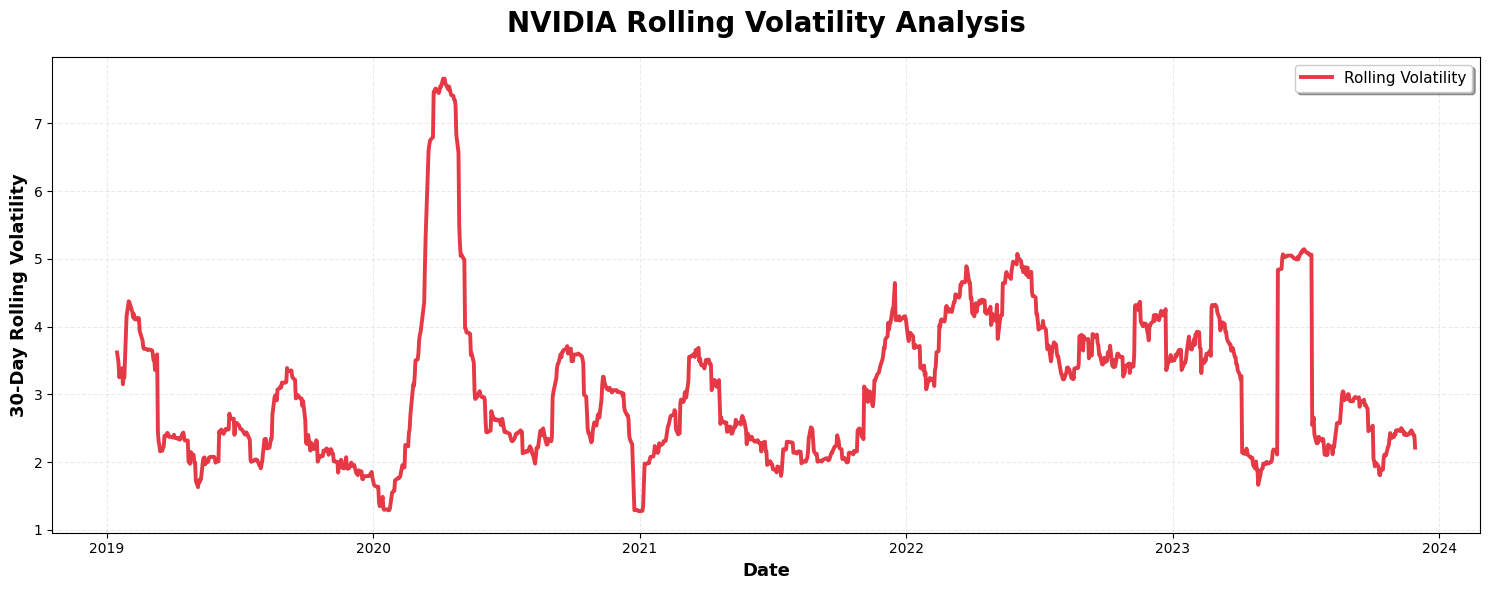

In [114]:
plt.figure(figsize=(15,6))

plt.plot(nvda_df["Date"],nvda_df["Rolling_Volatility"],linewidth=2.8,color="#E63946")

plt.title("NVIDIA Rolling Volatility Analysis",fontsize=20,fontweight="bold",pad=18)

plt.xlabel("Date",fontsize=13,fontweight="bold")

plt.ylabel("30-Day Rolling Volatility",fontsize=13,fontweight="bold")

plt.grid(alpha=0.25,linestyle="--")

plt.legend(["Rolling Volatility"],fontsize=11,frameon=True,shadow=True)

plt.tight_layout()

plt.show()

<p><i>
Volatility measures market instability and stock price fluctuation intensity. 
The graph shows that 2020 experienced the highest volatility in NVIDIA stock prices.
</i></p>

In [115]:
# Trend Logic

conditions = [
    nvda_df["Close"] > nvda_df["Days_30"],
    nvda_df["Close"] < nvda_df["Days_30"]
]

choices = [ "Bullish","Bearish"]

nvda_df["Trend_Signal"] = np.select(conditions,choices,default="Sideways")

In [116]:
nvda_df["Trend_Signal"].value_counts()

Trend_Signal
Bullish     827
Bearish     402
Sideways     29
Name: count, dtype: int64

<p><i> Trend signals help identify bullish, bearish, and sideways market phases. </p></i>

In [117]:
# Financial Summary Table

comparison_table = (
    df.groupby("Company").agg({"Close": "mean","Daily_Return": "mean","Volume": "mean","Price_Range": "mean"}))
comparison_table.columns = ["Average_Close","Average_Return", "Average_Volume","Average_Price_Range"]
comparison_table

,Average_Close,Average_Return,Average_Volume,Average_Price_Range
Company,,,,
AAPL,118.992628,0.139173,1.038025e+08,2.666117
AMZN,126.463004,0.070088,7.762398e+07,3.233244
GOOGL,96.811996,0.092665,3.387009e+07,2.166584
MSFT,227.210645,0.121098,2.978487e+07,4.829582
NVDA,169.840709,0.253405,4.670900e+07,6.477961
TSLA,167.153725,0.274280,1.339275e+08,7.905675


<p><i>
GOOGL is the most stable stock because it has the lowest average price range. 
    
TSLA is the most volatile stock because it has the highest average price movement. 

TSLA also has the highest average trading volume, showing strong market activity. 

TSLA and NVDA provide the highest average returns among all companies.
</i></p>

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
ARIMA Forecasting</b>
</h1>

In [118]:
arima_model = ARIMA(nvda_df["Close"],order=(5,1,0))
arima_result = arima_model.fit()

In [119]:
forecast = arima_result.forecast(steps=30)
forecast

6290    479.807930
6291    479.118996
6292    479.463448
6293    479.150414
6294    479.364659
6295    479.294575
6296    479.243789
6297    479.268613
6298    479.245142
6299    479.263115
6300    479.257830
6301    479.254072
6302    479.255810
6303    479.254035
6304    479.255530
6305    479.255133
6306    479.254855
6307    479.254972
6308    479.254837
6309    479.254960
6310    479.254931
6311    479.254910
6312    479.254918
6313    479.254907
6314    479.254918
6315    479.254915
6316    479.254914
6317    479.254914
6318    479.254914
6319    479.254914
Name: predicted_mean, dtype: float64

In [121]:
train = nvda_df[:-30]
test = nvda_df[-30:]

In [122]:
comparison_df = pd.DataFrame({
    "Actual": test["Close"].values,
    "Forecast": forecast.values
})

comparison_df

,Actual,Forecast
0,421.959992,479.807930
1,421.010010,479.118996
2,413.869995,479.463448
3,429.750000,479.150414
4,436.630005,479.364659
5,417.790008,479.294575
6,403.260010,479.243789
7,405.000000,479.268613
8,411.609985,479.245142
9,407.799988,479.263115


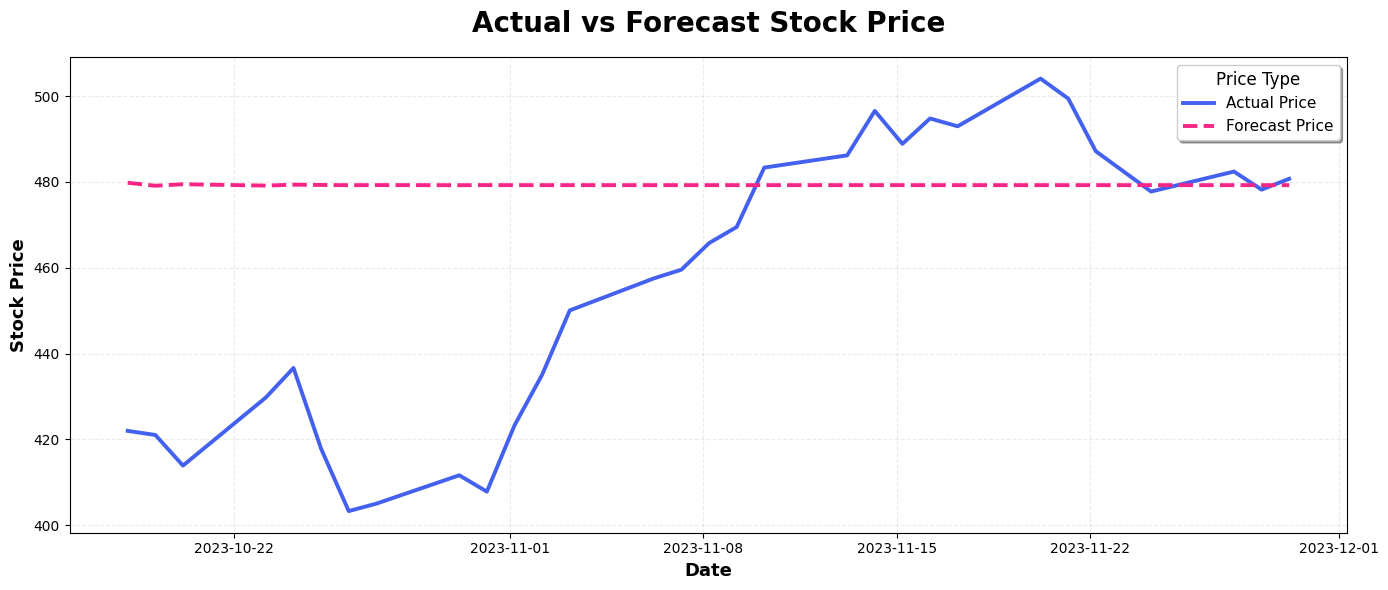

In [123]:
plt.figure(figsize=(14,6))

# Actual Price
plt.plot(test["Date"],test["Close"],label="Actual Price",linewidth=2.8,color="#4361EE")

# Forecast Price
plt.plot(test["Date"],forecast,label="Forecast Price",linewidth=2.8,color="#F72585",linestyle="--")

plt.title("Actual vs Forecast Stock Price",fontsize=20,fontweight="bold",pad=18)

plt.xlabel("Date",fontsize=13,fontweight="bold")

plt.ylabel("Stock Price",fontsize=13,fontweight="bold")

plt.legend(fontsize=11,title="Price Type",title_fontsize=12,frameon=True,shadow=True)

plt.grid(alpha=0.25,linestyle="--")

plt.tight_layout()

plt.show()

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Prophet Forecasting</b>
</h1>

In [125]:
forecast_df = nvda_df[["Date", "Close"]].copy()

In [127]:
forecast_df.columns = ["ds","y"]

In [129]:
forecast_df["ds"] = (pd.to_datetime(forecast_df["ds"]).dt.tz_localize(None))

In [130]:
prophet_model = Prophet()
prophet_model.fit(forecast_df)

17:39:53 - cmdstanpy - INFO - Chain [1] start processing
17:39:55 - cmdstanpy - INFO - Chain [1] done processing


In [131]:
future = prophet_model.make_future_dataframe(periods=30)

In [132]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-11-29 05:00:00,34.698751,32.316320,79.830362,34.698751,34.698751,21.564208,21.564208,21.564208,14.492790,14.492790,14.492790,7.071418,7.071418,7.071418,0.0,0.0,0.0,56.262958
1,2018-11-30 05:00:00,34.633194,30.872106,77.776684,34.633194,34.633194,19.450224,19.450224,19.450224,13.075810,13.075810,13.075810,6.374414,6.374414,6.374414,0.0,0.0,0.0,54.083418
2,2018-12-03 05:00:00,34.436525,29.651461,76.711728,34.436525,34.436525,18.382340,18.382340,18.382340,14.324662,14.324662,14.324662,4.057678,4.057678,4.057678,0.0,0.0,0.0,52.818865
3,2018-12-04 05:00:00,34.370969,28.591781,74.573605,34.370969,34.370969,16.845759,16.845759,16.845759,13.597628,13.597628,13.597628,3.248131,3.248131,3.248131,0.0,0.0,0.0,51.216727
4,2018-12-06 05:00:00,34.239856,26.986170,72.463015,34.239856,34.239856,16.128881,16.128881,16.128881,14.492790,14.492790,14.492790,1.636091,1.636091,1.636091,0.0,0.0,0.0,50.368737


In [135]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)

,ds,yhat,yhat_lower,yhat_upper
1258,2023-11-30 05:00:00,525.056215,501.691075,547.981141
1259,2023-12-01 05:00:00,523.893681,501.447315,545.186450
1260,2023-12-02 05:00:00,473.946526,450.249411,497.142773
1261,2023-12-03 05:00:00,479.277267,455.788543,501.415340
1262,2023-12-04 05:00:00,525.732018,503.642518,548.463914
1263,2023-12-05 05:00:00,525.180439,502.663992,548.839710
1264,2023-12-06 05:00:00,525.314265,501.801081,547.215869
1265,2023-12-07 05:00:00,526.454792,502.270651,549.059367
1266,2023-12-08 05:00:00,525.258482,502.371275,548.889894
1267,2023-12-09 05:00:00,475.344420,451.561619,498.274237


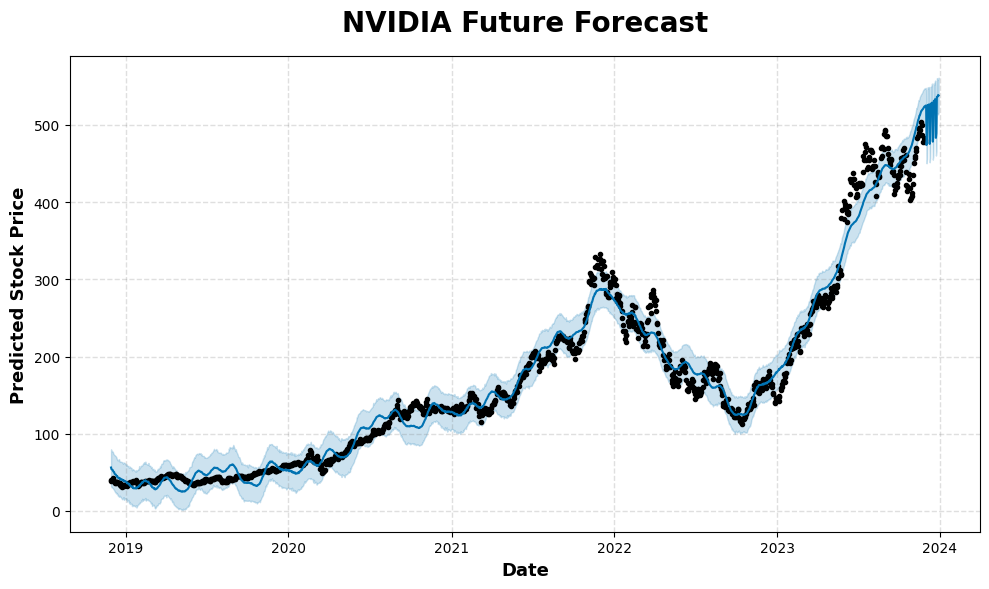

In [134]:
fig = prophet_model.plot(forecast)

plt.title("NVIDIA Future Forecast",fontsize=20,fontweight="bold",pad=18)

plt.xlabel("Date",fontsize=13,fontweight="bold")

plt.ylabel("Predicted Stock Price",fontsize=13,fontweight="bold")
plt.grid(alpha=0.25,linestyle="--")
plt.tight_layout()
plt.show()

<p><i>The Prophet model captured NVIDIA’s overall upward growth trend and predicted possible future stock price movement.</p></i>

In [136]:
# Train-Test Split
train_size = int(len(nvda_df) * 0.8)

train = nvda_df[:train_size]
test = nvda_df[train_size:]

In [137]:
# Train-Test Split
train_size = int(len(nvda_df) * 0.8)

train = nvda_df[:train_size]
test = nvda_df[train_size:]

In [143]:
arima_forecast = arima_result.forecast(
    steps=len(test)
)

# Mean Absolute Error
mae = mean_absolute_error(test["Close"],arima_forecast)
mae

143.08713285037874

In [146]:
# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(test["Close"],arima_forecast))
rmse

np.float64(182.7978249543697)

<p><i> Lower error values indicate better forecasting performance. </p></i>

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Save Clean Dataset</b>
</h1>

In [147]:
df.to_csv("cleaned_stock_market_dataset.csv",index=False)

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Final Business Insights</b>
</h1>

1. **NVIDIA** showed the highest long-term growth among all companies. Its stock price increased from below $ 50 in 2018 to above $ 480 in 2023, mainly because of the rapid growth of the AI industry.

2. **Tesla** showed the highest volatility and biggest price movement. The stock price increased and decreased very quickly, making it a high-risk but high-return stock.

3. **Apple, Microsoft, Amazon, and Google** showed more stable and steady growth compared to NVIDIA and Tesla. Their stock prices moved more smoothly with lower daily fluctuations.

4. Daily return analysis showed that **NVIDIA and Tesla** had larger daily price changes, while **Apple, Microsoft, Google, and Amazon** had smaller and more stable daily movements.

5. The **7-day and 30-day moving averages** helped identify short-term and long-term market trends more clearly by smoothing stock price movement.

6. Volatility analysis showed that **NVIDIA** experienced very high market fluctuation, especially during **2020**, which reflected higher market uncertainty and risk.

7. Trading volume analysis showed that **Tesla** had the highest average trading activity, followed by **Apple and Amazon**. This means these stocks had stronger investor participation.

8. Financial comparison showed that **Tesla and NVIDIA** generated the highest average returns, while **Google** remained the most stable stock with lower price fluctuation.

9. **ARIMA** forecasting gave stable future price estimates for NVIDIA stock, while **Prophet** forecasting showed a possible upward future trend.

10. This project showed how financial time-series analysis techniques like **rolling averages, volatility analysis, return analysis, and forecasting** can help understand stock market behavior and future trend patterns.

<h1 style="color:#1A5C38 ; font-family:Georgia"> <b>
Conclusion</b>
</h1>
This project successfully performed end-to-end financial time-series analytics using historical stock market data.

The project covered:

data cleaning
datetime analytics
feature engineering
trend analysis
rolling statistics
volatility analysis
comparative financial analytics
ARIMA forecasting
Prophet forecasting
financial insight